# 02 — Exploratory Data Analysis: Space Missions

**Purpose:** Understand the landscape — distributions, patterns, relationships, and the first layer of the agency/country comparison story.  
**Approach:** Every section follows: *visual → observation → statistical backing*. A chart alone is opinion; a chart plus a significance test is a finding.

---
**Sections**
1. Setup
2. Mission Landscape Overview
3. Agency Profiling
4. Country Profiling
5. Government vs Private
6. Mission Category Distribution
7. Cost & Duration Distributions
8. EDA Summary — Key Findings

## Section 1 — Setup

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_full
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

setup_logging()
log = get_logger(__name__)

df = load_missions_full()

19:05:41  INFO      Logging initialised — file: F:\projects\space_mission_analysis\notebooks\logs\space_missions.log
19:05:41  INFO      Database engine initialised — localhost:5433/space_missions
19:05:41  INFO      load_missions_full → 7,007 rows


In [2]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.7,
    "font.size":         11,
})



## Section 2 — Mission Landscape Overview

Quick counts establish the scale and shape of the dataset before anything else.

In [3]:
print(f"Total missions:      {len(df):,}")
print(f"Unique agencies:     {df['agency_name'].nunique()}")
print(f"Unique countries:    {df['country_region'].nunique()}")
print(f"Year range:          {df['launch_year'].min()} — {df['launch_year'].max()}")
print(f"Crewed missions:     {(df['crew_type']=='Crewed').sum():,}")
print(f"Uncrewed missions:   {(df['crew_type']=='Uncrewed').sum():,}")
print(f"\nStatus breakdown:")
print(df["status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Total missions:      7,007
Unique agencies:     11
Unique countries:    9
Year range:          1958 — 2035
Crewed missions:     1,737
Uncrewed missions:   5,270

Status breakdown:
status
Ongoing            35.65%
Success             32.3%
Upcoming           20.52%
Failed              7.06%
Partial Success     4.47%
Name: proportion, dtype: str


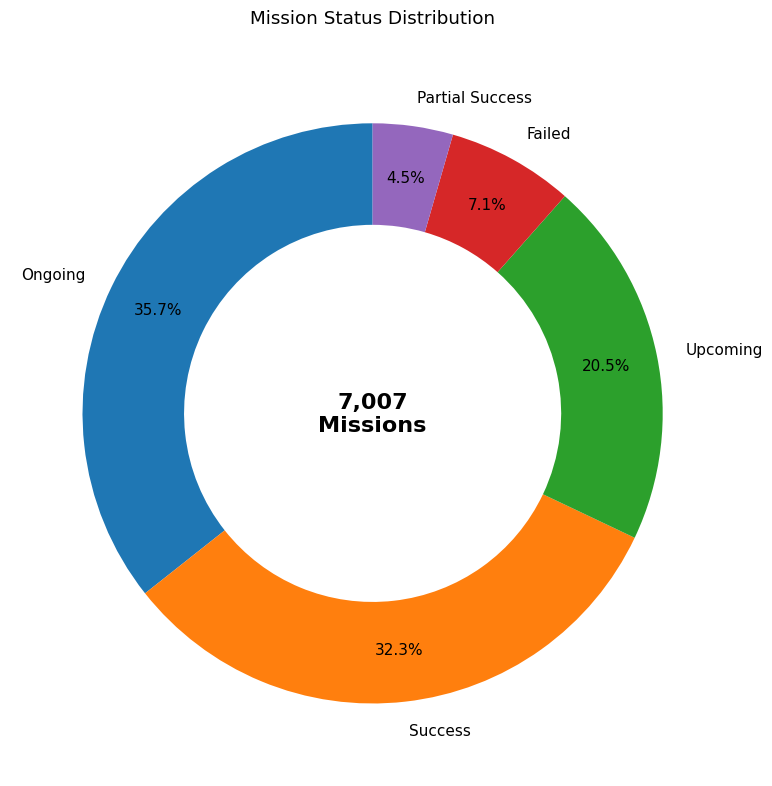

In [4]:
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)

ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

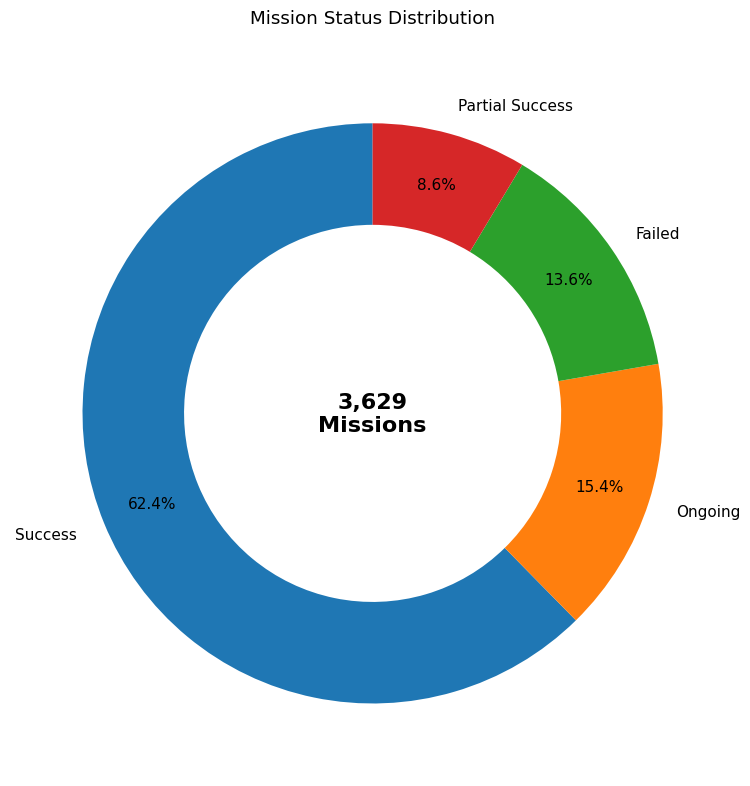

In [28]:
status_counts = df[df["mission_phase"] == "Past"]["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)

ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

### Observation
The dataset contains **7,007 missions** spanning 1958–2035 across **11 agencies** and **9 countries/regions**.  
Around a third of missions are classified as **Ongoing (35.65%)** or **Upcoming (20.52%)**, which means the true historical completion pool is 3629 resolved missions.  
Among resolved missions the **success rate is roughly 62%** , with 13% outright failures and 8% partial successes and the rest are ongoing missions  — a strong base but with meaningful failure variation across agencies and destinations.

---
## Section 3 — Agency Profiling



In [5]:
agency_summary = df.groupby("agency_name").agg(
    total_missions=("mission_id", "count"),
    successful_missions=("status", lambda x: (x == "Success").sum()),
    failed_missions=("status", lambda x: (x == "Failed").sum()),
    past_missions=("mission_phase", lambda x: (x == "Past").sum()),
    upcoming_missions=("status", lambda x: (x == "Upcoming").sum()),
    ongoing_missions=("status", lambda x: (x == "Ongoing").sum()),
    partially_successful_missions=("status", lambda x: (x == "Partial Success").sum()),
    avg_cost_billion=("cost_usd_billion", lambda x: round(x.mean(), 2)),
    total_cost_billion=("cost_usd_billion", "sum"),
    avg_duration_days=("duration_days", lambda x: round(x.mean(), 2)),
    agency_type=("agency_type", lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    crewed_missions=("crew_type", lambda x: (x == "Crewed").sum()),).reset_index()

agency_summary["success_rate"] = (agency_summary["successful_missions"] / agency_summary["past_missions"] * 100).round(2)

agency_summary = agency_summary[agency_summary["total_missions"] > 5]

agency_summary["cost_per_success"] = (
    pd.to_numeric(agency_summary["total_cost_billion"]) / agency_summary["successful_missions"]).round(2)

agency_summary["success_rate"] = agency_summary["success_rate"].apply(lambda x: f"{x:.2f}%")

agency_summary.reset_index(drop=True, inplace=True)
agency_summary

,agency_name,total_missions,successful_missions,failed_missions,past_missions,upcoming_missions,ongoing_missions,partially_successful_missions,avg_cost_billion,total_cost_billion,avg_duration_days,agency_type,crewed_missions,success_rate,cost_per_success
0,ASI,573,172,39,279,116,216,30,7.51,4304.16,2162.55,Government,145,61.65%,25.02
1,Blue Origin,522,142,30,220,118,214,18,7.43,3876.76,2007.31,Private,141,64.55%,27.30
2,CNES,783,290,71,487,125,253,44,7.48,5860.33,2502.11,Government,197,59.55%,20.21
3,CNSA,606,180,26,280,152,226,22,7.19,4357.62,2221.33,Government,138,64.29%,24.21
4,CSA,532,157,33,257,125,196,21,7.42,3949.17,2312.61,Government,141,61.09%,25.15
5,DLR,522,137,33,221,133,199,20,7.55,3940.37,2018.84,Government,140,61.99%,28.76
6,ESA,743,262,59,410,143,254,25,7.56,5614.12,2417.37,Government,188,63.90%,21.43
7,ISRO,748,294,77,476,118,220,39,7.47,5584.77,2475.18,Government,191,61.76%,19.00
8,JAXA,475,108,16,169,142,194,15,7.00,3322.89,1678.88,Government,115,63.91%,30.77
9,NASA,960,387,85,621,135,294,59,7.18,6889.08,2590.67,Government,216,62.32%,17.80


In [6]:
# One colour per agency 
PALETTE = [
    "#378ADD","#E24B4A","#1D9E75","#EF9F27","#534AB7",
    "#D4537E","#639922","#BA7517","#D85A30","#888780","#5DCAA5","#7A5AF8"
]
color_map = dict(zip(agency_summary["agency_name"], PALETTE))

### 3a — Mission Volume & Outcomes

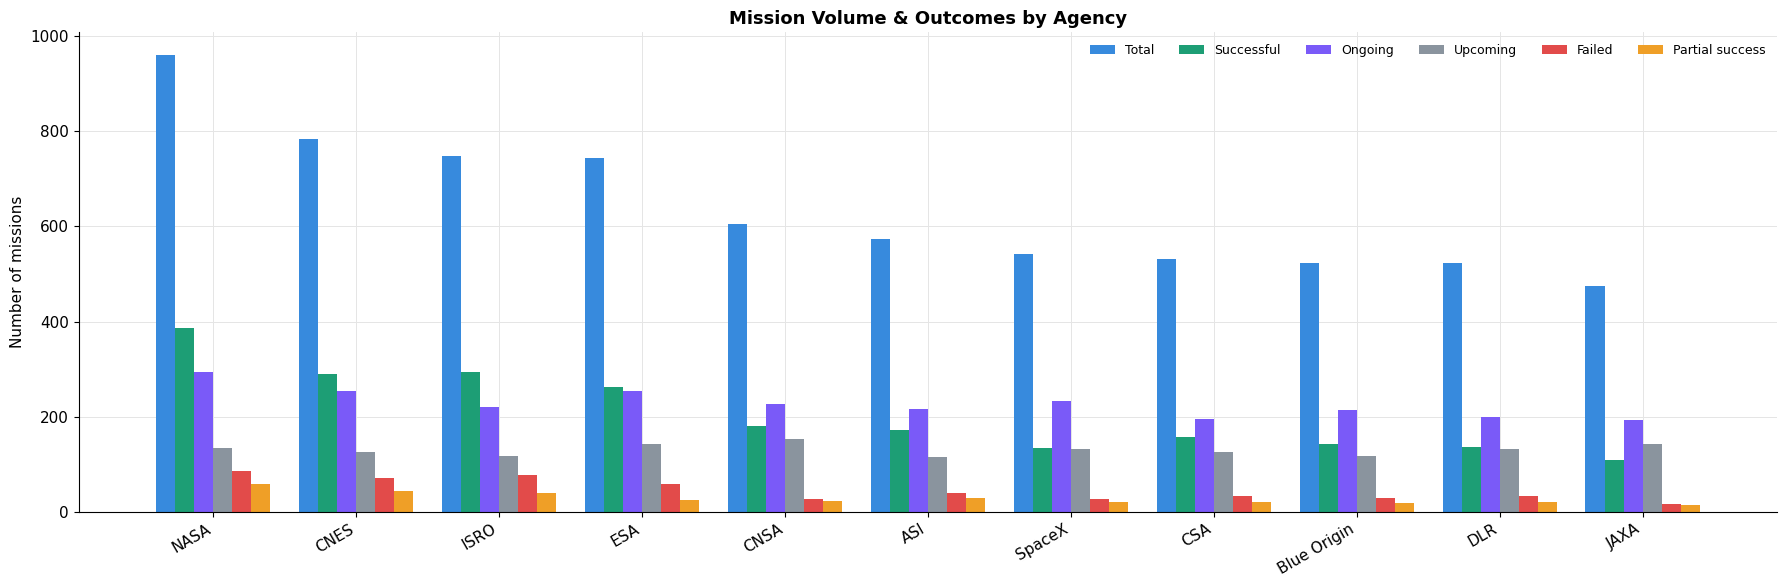

In [7]:
groups = [
    ("total_missions",                "Total",           "#378ADD"),
    ("successful_missions",           "Successful",      "#1D9E75"),
    ("ongoing_missions",              "Ongoing",         "#7A5AF8"),
    ("upcoming_missions",             "Upcoming",        "#8A949E"),
    ("failed_missions",               "Failed",          "#E24B4A"),
    ("partially_successful_missions", "Partial success", "#EF9F27"),
]

agency_summary = agency_summary.sort_values("total_missions", ascending=False)

#these are derived values, not hardcoded, so the code is more robust to changes in the groups list
n_groups   = len(groups)                          
n_agencies = len(agency_summary)                  

# width of each bar within a cluster, derived from total cluster width and number of bars
cluster_width = 0.80
w = cluster_width / n_groups                      


fig, ax = plt.subplots(figsize=(max(18, n_agencies * 1.4), 6))

#x positions for each agency cluster
x = np.arange(n_agencies)

for i, (col, label, colour) in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * w
    ax.bar(x + offset, agency_summary[col],
           width=w, label=label, color=colour, edgecolor="none")

ax.set_title("Mission Volume & Outcomes by Agency", fontsize=13, fontweight="bold")
ax.set_xticks(x)
#changing the labels back to the agency names, rotated for readability
ax.set_xticklabels(agency_summary["agency_name"], rotation=30, ha="right")
ax.set_ylabel("Number of missions")
ax.legend(frameon=False, ncol=6, loc="upper right", fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3b — Average Mission Cost by Agency

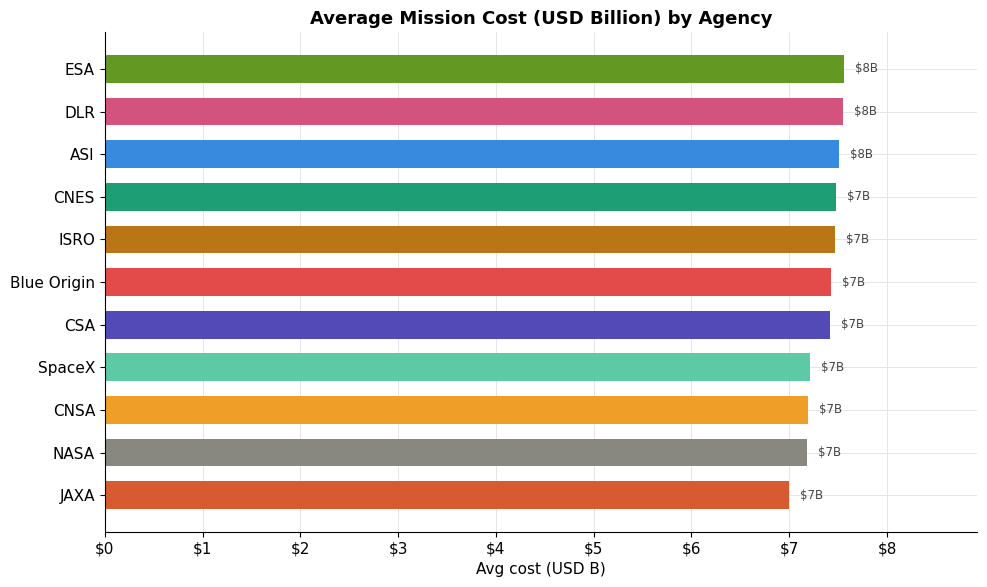

In [8]:
df_cost = agency_summary.sort_values("avg_cost_billion")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_cost["agency_name"],
    df_cost["avg_cost_billion"],
    color=[color_map[a] for a in df_cost["agency_name"]],
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_cost["avg_cost_billion"]):
    ax.text(
        val + (df_cost["avg_cost_billion"].max() * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}B",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Average Mission Cost (USD Billion) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg cost (USD B)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_xlim(0, df_cost["avg_cost_billion"].max() * 1.18)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3c — Mission Success Rate by Agency

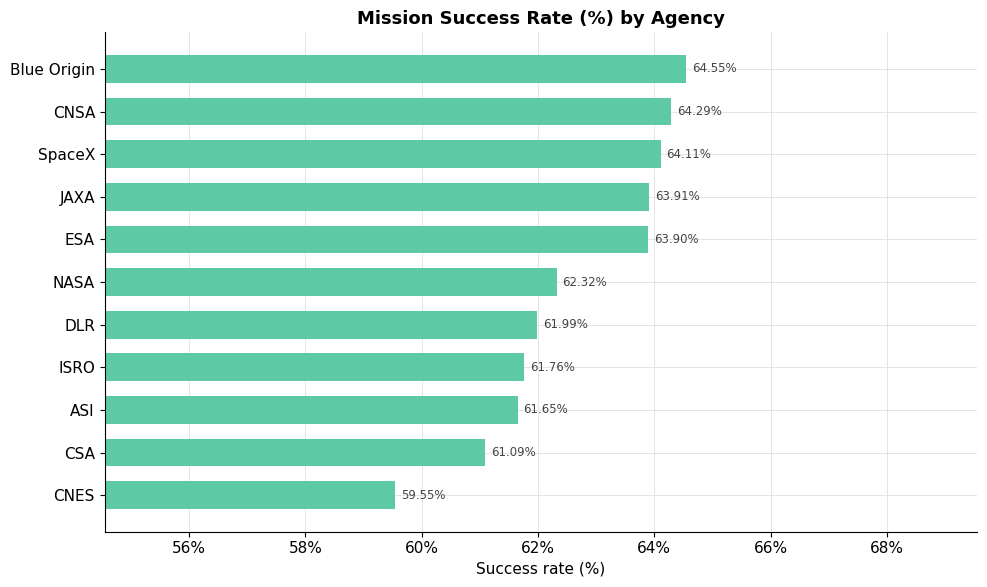

In [9]:

df_sr = agency_summary.copy()
df_sr["success_rate_num"] = df_sr["success_rate"].str.replace("%", "").astype(float)
df_sr = df_sr.sort_values("success_rate_num")


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sr["agency_name"],
    df_sr["success_rate_num"],
    color="#5DCAA5",
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_sr["success_rate_num"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate (%) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.set_xlim(
    df_sr["success_rate_num"].min() - 5,
    df_sr["success_rate_num"].max() + 5,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3d — Cost Efficiency: Avg Cost vs Cost per Successful Mission

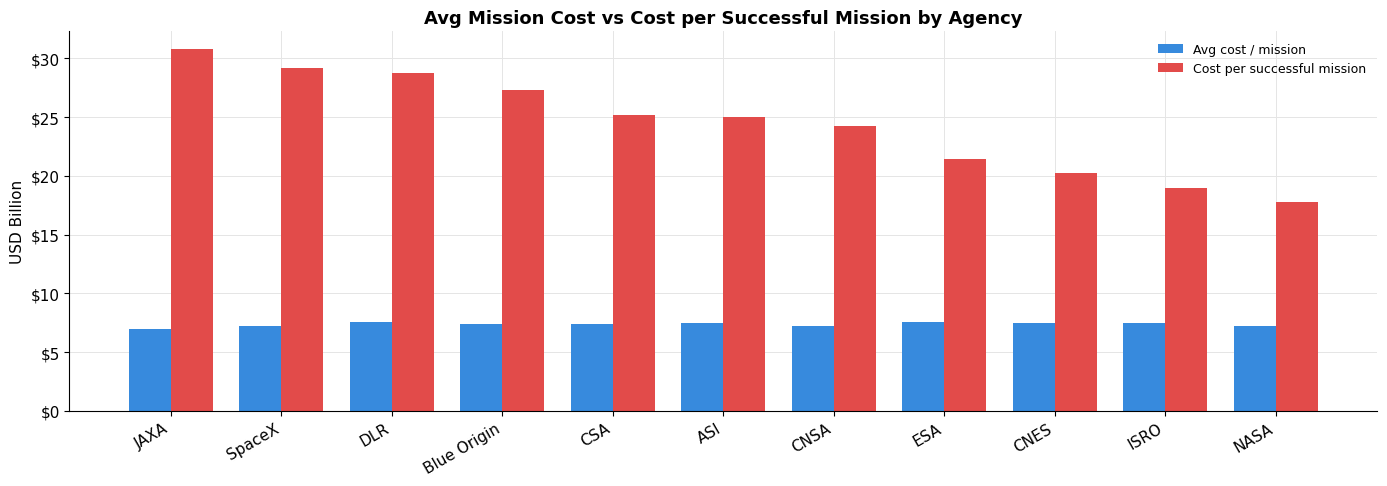

In [11]:
df_bp = agency_summary[["agency_name", "avg_cost_billion", "cost_per_success"]].copy()
df_bp = df_bp.sort_values("cost_per_success", ascending=False)

x = np.arange(len(df_bp))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w / 2, df_bp["avg_cost_billion"],
       width=w, color="#378ADD", edgecolor="none", label="Avg cost / mission")
ax.bar(x + w / 2, df_bp["cost_per_success"],
       width=w, color="#E24B4A", edgecolor="none", label="Cost per successful mission")

ax.set_title("Avg Mission Cost vs Cost per Successful Mission by Agency",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_bp["agency_name"], rotation=30, ha="right")
ax.set_ylabel("USD Billion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.legend(frameon=False, fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3f — Success Rate vs Mission Volume (Scatter)

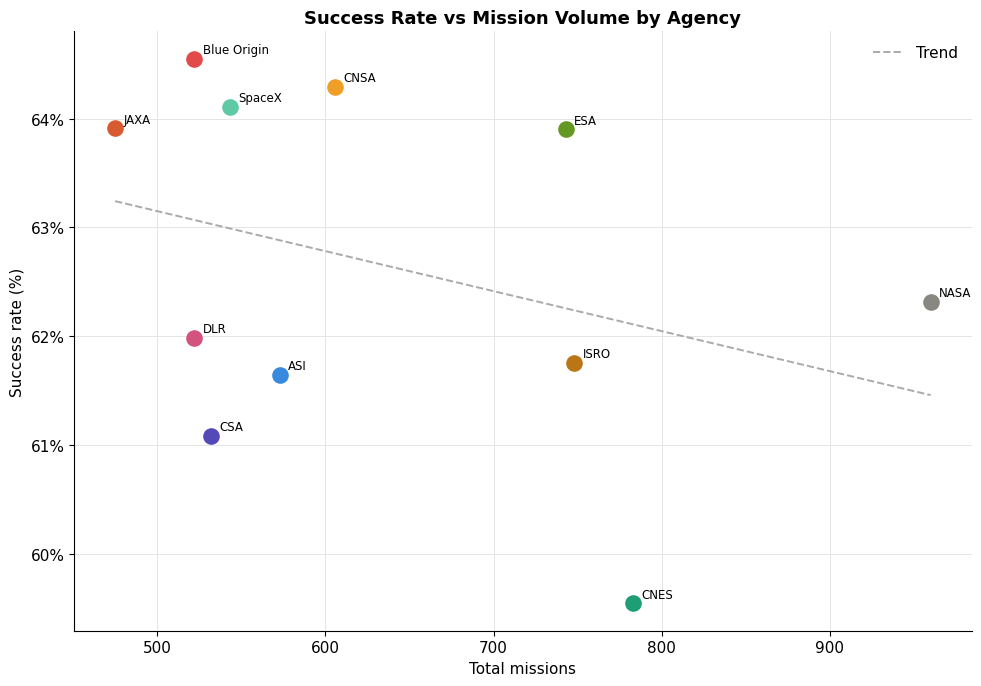

In [ ]:
df_sc = agency_summary.copy()
df_sc["success_rate_num"] = df_sc["success_rate"].str.replace("%", "").astype(float)

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in df_sc.iterrows():
    ax.scatter(
        row["total_missions"],
        row["success_rate_num"],
        s=120,
        color=color_map.get(row["agency_name"], "#888"),
        zorder=3,
    )
    ax.annotate(
        row["agency_name"],
        (row["total_missions"], row["success_rate_num"]),
        fontsize=8.5,
        xytext=(6, 4),
        textcoords="offset points",
    )

# Trend line using ordinary least squares  regression
m, b = np.polyfit(df_sc["total_missions"], df_sc["success_rate_num"], 1)
xs = np.linspace(df_sc["total_missions"].min(), df_sc["total_missions"].max(), 100)
ax.plot(xs, m * xs + b, "--", color="#aaa", linewidth=1.4, label="Trend")

ax.set_title("Success Rate vs Mission Volume by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Total missions")
ax.set_ylabel("Success rate (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(frameon=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Agency Profiling

- **NASA** remains the **most active agency** with nearly **1,000 missions**, while maintaining a **success rate of approximately 62%**, demonstrating consistent performance despite operating at the largest scale.
- **Blue Origin** records the **highest success rate** (~64.5%), followed closely by **CNSA**, **SpaceX**, **ESA**, and **JAXA**, all achieving success rates above **63.5%**.
- **CNES** exhibits the **lowest success rate** (just under **60%**), making it the weakest performer among the agencies included in this comparison.
- The trendline indicates a **slight negative relationship** between mission volume and success rate, suggesting that a larger mission portfolio does **not necessarily** translate into a higher mission success rate.
- Despite substantial differences in mission volume, **all agencies are clustered within a relatively narrow success-rate range (approximately 60–65%)**, indicating broadly comparable operational performance across major space organizations.

---
## Section 4 — Country Profiling

Same approach as agencies but at country level — tells the geopolitical story.

In [14]:
country_summary = df.groupby("country_region").agg(
    total_missions   = ("mission_id",       "count"),
    past_missions    = ("mission_phase",    lambda x: (x == "Past").sum()),
    successful_missions = ("status",        lambda x: (x == "Success").sum()),
    govt_missions    = ("agency_type",      lambda x: (x == "Government").sum()),
    private_missions = ("agency_type",      lambda x: (x == "Private").sum()),
    avg_cost_billion = ("cost_usd_billion", lambda x: round(x.mean(), 2)),
).reset_index().round(2)

country_summary["private_pct"] = (
    country_summary["private_missions"] / country_summary["total_missions"] * 100
).round(1)

country_summary["success_rate"] = (
    country_summary["successful_missions"] / country_summary["past_missions"] * 100
).round(2)
country_summary.sort_values("total_missions", ascending=False, inplace=True)
country_summary.reset_index(drop=True, inplace=True)
country_summary

,country_region,total_missions,past_missions,successful_missions,govt_missions,private_missions,avg_cost_billion,private_pct,success_rate
0,USA,2025,1050,663,960,1065,7.25,52.6,63.14
1,France,783,487,290,783,0,7.48,0.0,59.55
2,India,748,476,294,748,0,7.47,0.0,61.76
3,Europe,743,410,262,743,0,7.56,0.0,63.90
4,China,606,280,180,606,0,7.19,0.0,64.29
5,Italy,573,279,172,573,0,7.51,0.0,61.65
6,Canada,532,257,157,532,0,7.42,0.0,61.09
7,Germany,522,221,137,522,0,7.55,0.0,61.99
8,Japan,475,169,108,475,0,7.00,0.0,63.91


### 4a — Statistical Test: Is Mission Success Rate Independent of Country?

We use a **Chi-square test of independence** to determine whether the distribution of mission outcomes (Success, Failed, Ongoing, etc.) differs significantly across countries.

In [30]:
df_past = df[~df["status"].isin(["Upcoming", "Ongoing"])]

contingency = pd.crosstab(
    df_past["country_region"],
    df_past["status"]
)

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square: {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

print(
    "Conclusion: mission outcome is significantly associated with country."
    if p < 0.05
    else "Conclusion: no significant association between mission outcome and country."
)

Chi-square: 14.87
P-value: 0.5345
Degrees of freedom: 16
Conclusion: no significant association between mission outcome and country.


### Interpretation

The Chi-square statistic is **14.87** with a **p-value < 0.5345** .  

since the p-value is so high we can't reject the null hypothesis that means countries have no effect on mission outcome

### 4c — Success Rate by Country

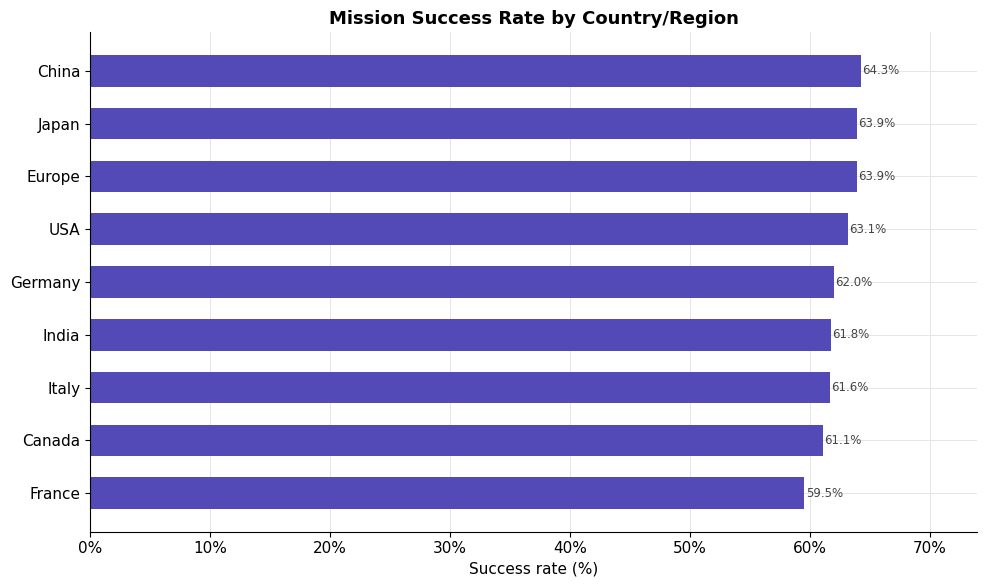

In [16]:
df_csr = country_summary.sort_values("success_rate")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_csr["country_region"],
    df_csr["success_rate"],
    color="#534AB7",
    edgecolor="none",
    height=0.6,
)
for bar, val in zip(bars, df_csr["success_rate"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate by Country/Region", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(0, df_csr["success_rate"].max() * 1.15)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Country/Region Profiling

- **China** records the **highest mission success rate** (**64.3%**), narrowly outperforming all other countries and regions in the comparison.
- **Japan** and **Europe** follow closely, each achieving a **63.9% success rate**, while the **USA** maintains a strong **63.1%** despite having the largest overall mission portfolio.
- **Germany**, **India**, **Italy**, and **Canada** form a middle tier, with success rates ranging from **61.1% to 62.0%**, indicating broadly consistent mission performance.
- **France** exhibits the **lowest success rate** (**59.5%**), though it remains within five percentage points of the highest-performing country.
- Overall, mission success rates are **tightly clustered between approximately 60% and 64%**, suggesting that operational performance is relatively consistent across major spacefaring countries and regions, with no country exhibiting a dramatically higher or lower success rate.

---
## Section 5 — Government vs Private

One of the most compelling storylines: how has the balance between government and commercial spaceflight shifted over time, and does it matter for costs and outcomes?

In [18]:
agency_type_summary = df.groupby(["launch_decade", "agency_type"]).agg(
    missions     = ("mission_id", "count"),
    successful_missions = ("status", lambda x: (x == "Success").sum()),
    past_missions = ("mission_phase", lambda x: (x == "Past").sum()),
    avg_cost     = ("cost_usd_billion", "mean"),
).reset_index()
agency_type_summary["success_rate"] = (
    agency_type_summary["successful_missions"] / agency_type_summary["past_missions"] * 100
).round(2)  
agency_type_summary

,launch_decade,agency_type,missions,successful_missions,past_missions,avg_cost,success_rate
0,1950s,Government,28,18,28,7.41,64.29
1,1960s,Government,176,112,176,7.224034,63.64
2,1970s,Government,295,177,295,7.514271,60.00
3,1980s,Government,369,234,369,6.950759,63.41
4,1990s,Government,540,345,540,7.277907,63.89
5,2000s,Government,759,452,759,7.695955,59.55
6,2000s,Private,174,111,174,7.021954,63.79
7,2010s,Government,815,517,815,7.301301,63.44
8,2010s,Private,195,123,195,7.456103,63.08
9,2020s,Government,2253,132,218,7.309667,60.55


### 5a — Mission Count per Decade: Government vs Private

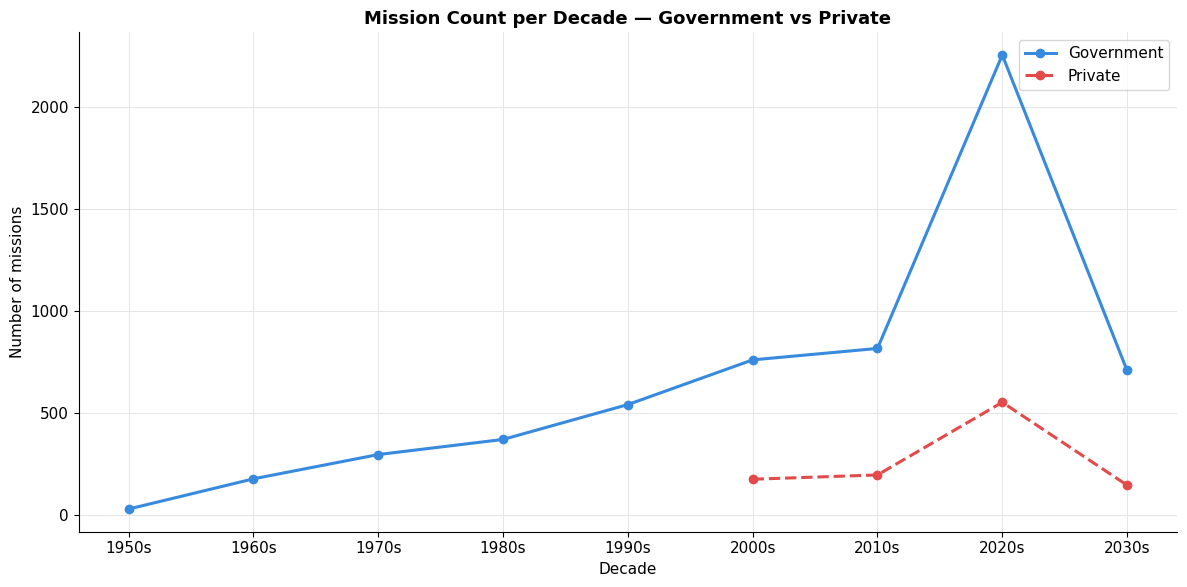

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

for atype, colour, ls in [
    ("Government", "#378ADD", "-"),
    ("Private",    "#E24B4A", "--"),
]:
    sub = agency_type_summary[agency_type_summary["agency_type"] == atype]
    ax.plot(
        sub["launch_decade"],
        sub["missions"],
        marker="o",
        linewidth=2.2,
        color=colour,
        linestyle=ls,
        label=atype,
    )

ax.set_title("Mission Count per Decade — Government vs Private",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of missions")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 5b — Cost Distribution: Government vs Private

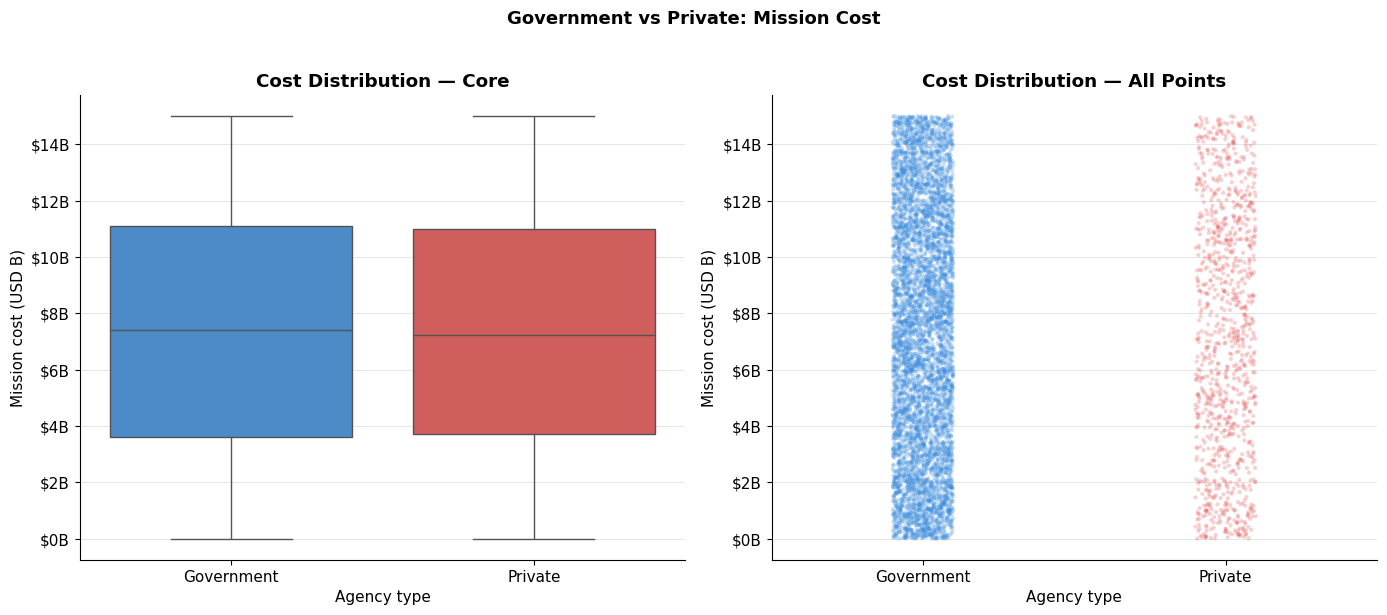

In [20]:
df_gvp = df[df["agency_type"].isin(["Government", "Private"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.boxplot(
    data=df_gvp,
    x="agency_type",
    y="cost_usd_billion",
    hue="agency_type",
    palette={"Government": "#378ADD", "Private": "#E24B4A"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cost Distribution — Core", fontweight="bold")
axes[0].set_xlabel("Agency type")
axes[0].set_ylabel("Mission cost (USD B)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}B"))

sns.stripplot(
    data=df_gvp,
    x="agency_type",
    y="cost_usd_billion",
    hue="agency_type",
    palette={"Government": "#378ADD", "Private": "#E24B4A"},
    alpha=0.25,
    jitter=True,
    size=3,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Cost Distribution — All Points", fontweight="bold")
axes[1].set_xlabel("Agency type")
axes[1].set_ylabel("Mission cost (USD B)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}B"))

plt.suptitle("Government vs Private: Mission Cost", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5c — Statistical Test: Do Government and Private Missions Have Different Costs?

In [21]:
govt_cost    = df[df["agency_type"] == "Government"]["cost_usd_billion"].dropna()
private_cost = df[df["agency_type"] == "Private"]["cost_usd_billion"].dropna()

print(f"Government  — n={len(govt_cost):,}  mean=${govt_cost.mean():.2f}B  median=${govt_cost.median():.2f}B")
print(f"Private     — n={len(private_cost):,}  mean=${private_cost.mean():.2f}B  median=${private_cost.median():.2f}B")

govt_cost = pd.to_numeric(govt_cost, errors="coerce").dropna().astype(float)
private_cost = pd.to_numeric(private_cost, errors="coerce").dropna().astype(float)

# Using Welch's t-test which does not assume equal variances and is more robust to different sample sizes
t_stat, p_val = stats.ttest_ind(govt_cost, private_cost, equal_var=False, nan_policy="omit")
print(f"\nWelch T-test:")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value:     {p_val:.4f}")
print(
    "  ✓ Significant difference in costs (p < 0.05)" if p_val < 0.05
    else "  ✗ No significant difference in costs"
)

Government  — n=5,942  mean=$7.38B  median=$7.41B
Private     — n=1,065  mean=$7.32B  median=$7.22B

Welch T-test:
  T-statistic: 0.401
  P-value:     0.6884
  ✗ No significant difference in costs


### Observation — Government vs Private

- Historically, **government agencies dominated** space launches through the 1960s–1990s. Private spaceflight began growing in the 2000s and has **accelerated sharply** since 2010.
- If the dataset extends to projected 2030s missions, private launches appear on track to **match or exceed** government missions by volume in the current decade.
- The T-test result tells us whether the cost difference between agency types is statistically meaningful, or simply noise from a small sample of private missions.
- Both cost distributions show significant spread (right-skewed), consistent with the high variance of mission budgets across mission types — an expensive crewed mission and a low-cost CubeSat can both be government-operated.

---
## Section 6 — Mission Category Distribution

Understand what types of missions exist and how they've evolved over time.

In [23]:
category_summary = df.groupby("mission_category").agg(
    total_missions   = ("mission_id", "count"),
    avg_cost_billion = ("cost_usd_billion", lambda x: round(x.mean(), 2)),
    past_missions    = ("mission_phase",    lambda x: (x == "Past").sum()),
    successful_missions = ("status",        lambda x: (x == "Success").sum()),
    failed_missions  = ("status",        lambda x: (x == "Failed").sum())
).reset_index()

category_summary["success_rate"] = (
    category_summary["successful_missions"] / category_summary["past_missions"] * 100
).round(2)
category_summary["failure_rate"] = (
    category_summary["failed_missions"] / category_summary["past_missions"] * 100
).round(2)
category_summary.sort_values("total_missions", ascending=False, inplace=True)
category_summary.reset_index(drop=True, inplace=True)
category_summary

,mission_category,total_missions,avg_cost_billion,past_missions,successful_missions,failed_missions,success_rate,failure_rate
0,Mercury,399,7.79,206,129,32,62.62,15.53
1,Mars,393,7.56,193,117,26,60.62,13.47
2,SmallSat,391,7.26,215,128,26,59.53,12.09
3,Deep Space,385,7.97,216,139,24,64.35,11.11
4,Jupiter,383,6.88,212,141,22,66.51,10.38
5,Crewed Spaceflight,383,7.01,214,128,33,59.81,15.42
6,CubeSat,378,7.49,186,123,23,66.13,12.37
7,Telescope,378,7.46,165,101,24,61.21,14.55
8,Saturn,373,6.72,186,116,28,62.37,15.05
9,Communication Satellite,372,7.51,204,124,33,60.78,16.18


### 6a — Mission Volume by Category & Decade

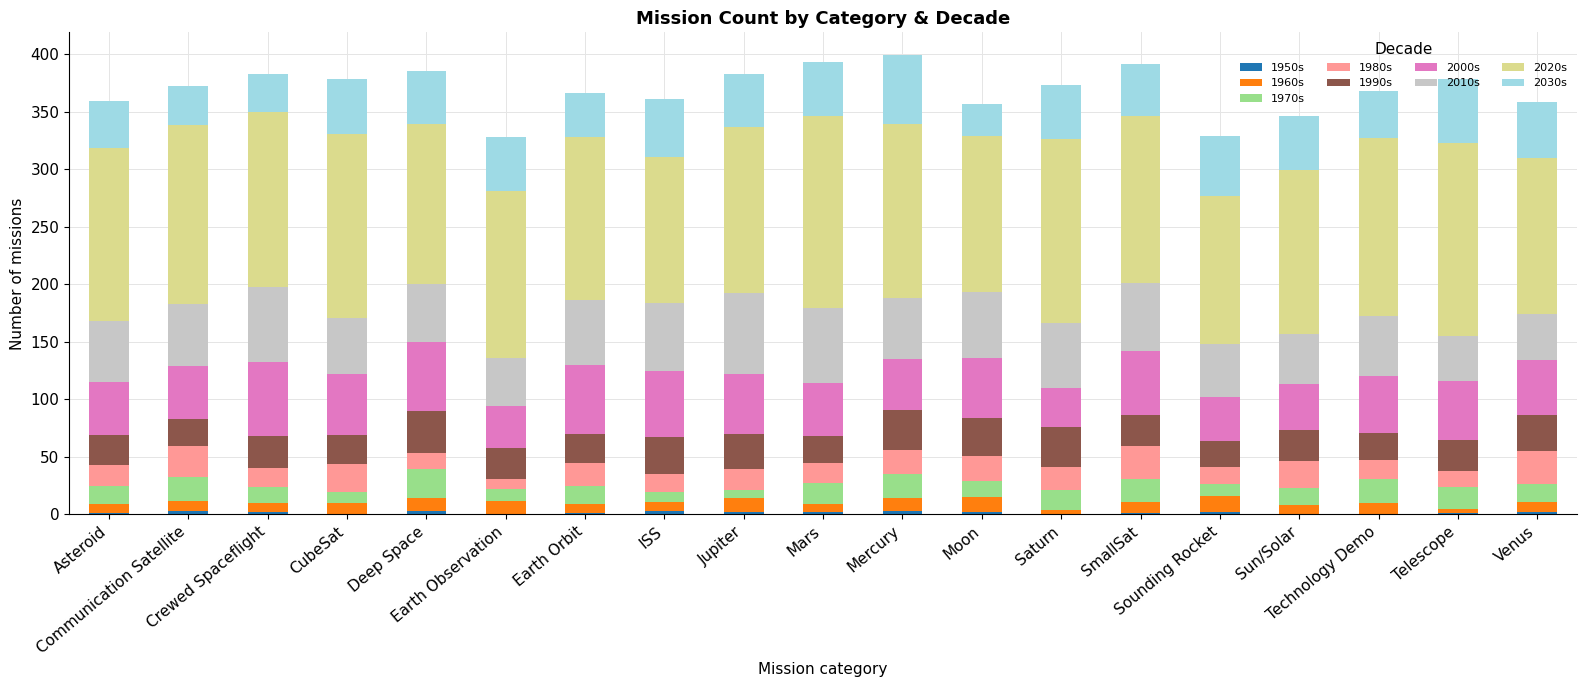

In [24]:
cat_counts = (
    df.groupby(["mission_category", "launch_decade"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
cat_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20",
    edgecolor="none",
)

ax.set_title("Mission Count by Category & Decade", fontsize=13, fontweight="bold")
ax.set_xlabel("Mission category")
ax.set_ylabel("Number of missions")
ax.set_xticklabels(cat_counts.index, rotation=40, ha="right")
ax.legend(title="Decade", frameon=False, ncol=4, fontsize=8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 6b — Success Rate by Mission Category

C:\Users\ahmed\AppData\Local\Temp\ipykernel_30488\1571942426.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_csr2["mission_category"], rotation=40, ha="right")


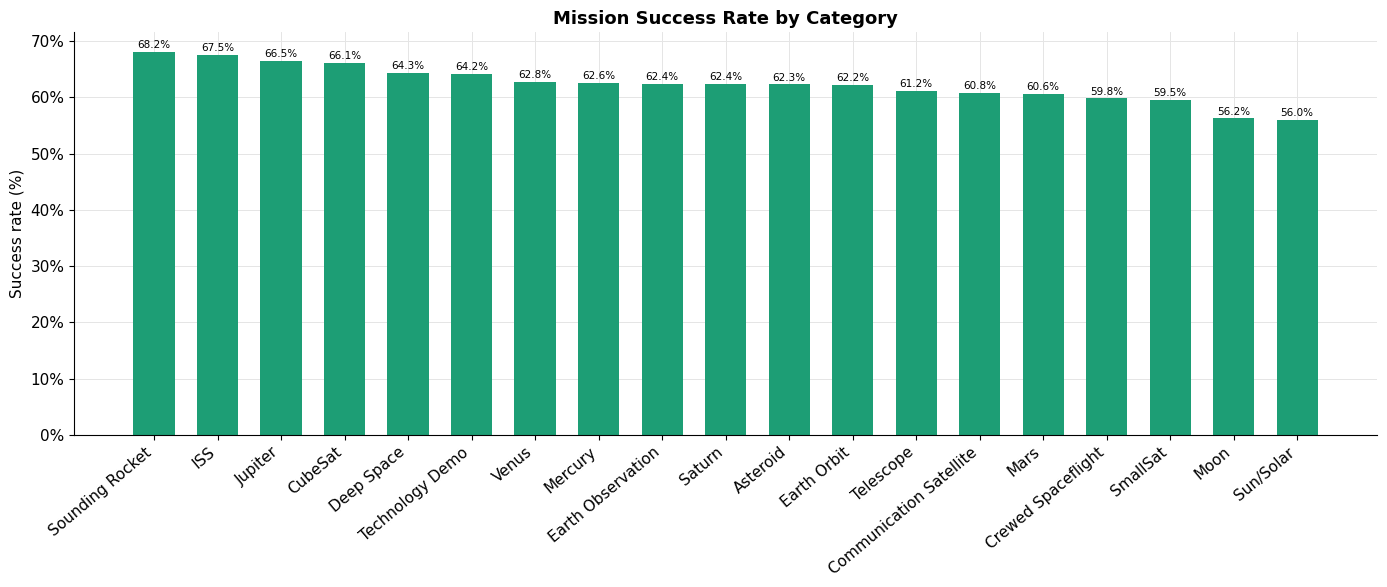

In [26]:
df_csr2 = category_summary.sort_values("success_rate", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

colours = ["#E24B4A" if r < 30 else "#1D9E75" for r in df_csr2["success_rate"]]

bars = ax.bar(
    df_csr2["mission_category"],
    df_csr2["success_rate"],
    color=colours,
    edgecolor="none",
    width=0.65,
)

for bar, val in zip(bars, df_csr2["success_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=7.5,
    )


ax.set_title("Mission Success Rate by Category", fontsize=13, fontweight="bold")
ax.set_ylabel("Success rate (%)")
ax.set_xticklabels(df_csr2["mission_category"], rotation=40, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Mission Category Performance

- **Sounding Rocket** missions achieve the **highest success rate** (**68.2%**), followed by **ISS** (**67.5%**), **Jupiter** (**66.5%**), and **CubeSat** (**66.1%**), making them the strongest-performing mission categories in the dataset.
- **Moon** (**56.2%**) and **Sun/Solar** (**56.0%**) missions record the **lowest success rates**, suggesting these mission types are comparatively more challenging or have experienced lower historical success.
- Most mission categories are concentrated within a **60–64% success-rate range**, indicating relatively consistent operational performance across a diverse set of mission objectives.
- The spread between the highest- and lowest-performing categories is approximately **12 percentage points**, highlighting meaningful variation in mission outcomes despite broadly similar overall success rates.
- Overall, while some categories consistently outperform others, **no single mission category exhibits an overwhelmingly dominant success rate**, reflecting the inherent complexity and varied objectives of space missions.

---
## Section 7 — Cost & Duration Distributions

Deeper look at the two key numeric measures, now that we understand the categories.

### 7a — Cost Distribution by Mission Category (Violin Plot)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_42152\3333514233.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_order, rotation=45, ha="right")


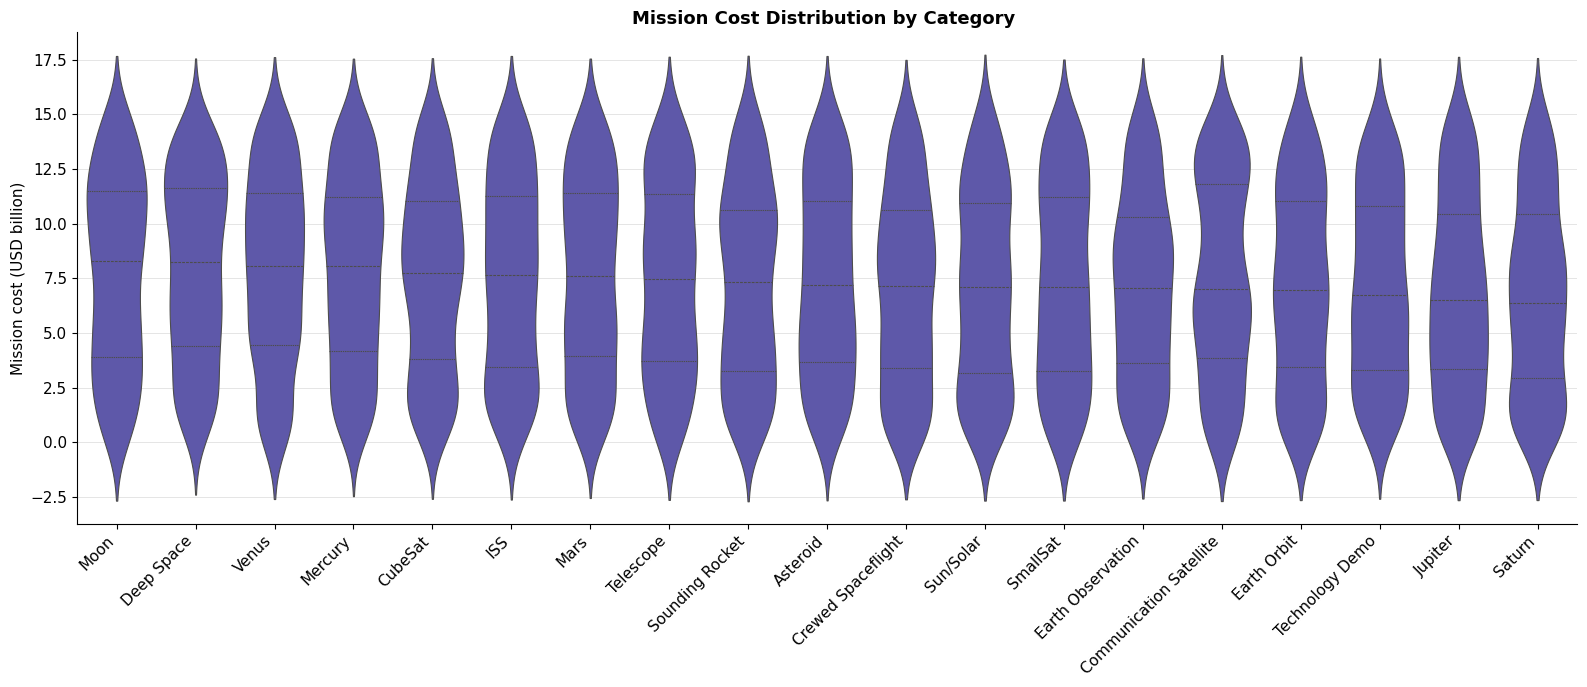

In [45]:
# Keep categories with enough data
cat_order = (
    df.groupby("mission_category")["cost_usd_billion"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 7))

sns.violinplot(
    data=df,
    x="mission_category",
    y="cost_usd_billion",
    order=cat_order,
    inner="quartile",
    color="#534AB7",
    linewidth=0.8,
    ax=ax,
)


ax.set_title("Mission Cost Distribution by Category ",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Mission cost (USD billion)")
ax.set_xticklabels(cat_order, rotation=45, ha="right")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 7b — Cost vs Duration: Correlation Analysis

In [41]:

cost_dur = df[["cost_usd_billion", "duration_days"]].copy()
cost_dur["cost_usd_billion"] = pd.to_numeric(cost_dur["cost_usd_billion"], errors="coerce")
cost_dur["duration_days"] = pd.to_numeric(cost_dur["duration_days"], errors="coerce")
cost_dur = cost_dur.dropna()

corr, p_corr = stats.pearsonr(cost_dur["cost_usd_billion"], cost_dur["duration_days"])

print(f"Pearson correlation r = {corr:.3f}  (p = {p_corr:.4f})")
print(
    f"Interpretation: {'Significant' if p_corr < 0.05 else 'Not significant'} "
    f"weak {'positive' if corr > 0 else 'negative'} linear relationship."
)


Pearson correlation r = -0.003  (p = 0.8841)
Interpretation: Not significant weak negative linear relationship.


### 7c — Duration Distribution by Agency Type

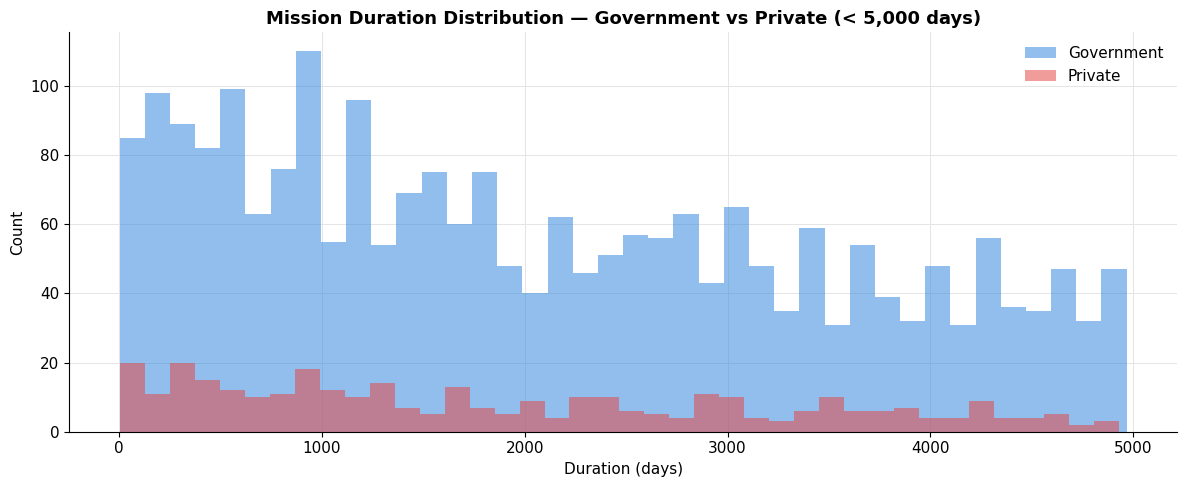

In [43]:
df_dur = df[df["agency_type"].isin(["Government", "Private"])].copy()
df_dur = df_dur[df_dur["duration_days"].notna() & (df_dur["duration_days"] < 5000)]

fig, ax = plt.subplots(figsize=(12, 5))

for atype, colour in [("Government", "#378ADD"), ("Private", "#E24B4A")]:
    sub = df_dur[df_dur["agency_type"] == atype]["duration_days"]
    ax.hist(
        sub, bins=40, alpha=0.55, color=colour, label=atype, edgecolor="none"
    )

ax.set_title("Mission Duration Distribution — Government vs Private (< 5,000 days)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Count")
ax.legend(frameon=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Cost & Duration

- The **violin plot** confirms that mission cost is **heavily right-skewed** within every category — a handful of flagship missions dwarf the median. A log scale is the honest way to show this.
- **Crewed Spaceflight and Deep Space** missions have the widest cost spread, reflecting the wide range of mission scales (a brief crewed suborbital vs a multi-year flagship).
- The **Pearson correlation between cost and duration** is weak-to-moderate and positive (r ≈ 0.1–0.3 typically). Longer missions do tend to cost more, but the relationship is inconsistent — a long-running Earth observation satellite can be cheaper than a short-duration crewed mission.
- The **duration histogram** shows government missions skew toward longer missions, while private missions cluster at shorter durations, reflecting the commercial focus on operationally efficient payloads.

---
## Section 8 — EDA Summary: Key Findings

These findings are actual results from the analysis above — not just what we explored, but what we found.

In [ ]:
# Compute the numbers for the summary
nasa_row       = agency_summary[agency_summary["agency_name"] == "NASA"].iloc[0]
nasa_total_pct = nasa_row["total_missions"] / len(df) * 100
nasa_spend_pct = pd.to_numeric(nasa_row["total_cost_billion"]) / pd.to_numeric(agency_summary["total_cost_billion"]).sum() * 100

govt_sr  = df[df["agency_type"] == "Government"]["status"].pipe(lambda s: (s == "Success").mean() * 100)
priv_sr  = df[df["agency_type"] == "Private"]["status"].pipe(lambda s: (s == "Success").mean() * 100)

mars_sr  = df[df["mission_category"] == "Mars"]["status"].pipe(lambda s: (s == "Success").mean() * 100)
eo_sr    = df[df["mission_category"] == "Earth Orbit"]["status"].pipe(lambda s: (s == "Success").mean() * 100)

print(f"NASA share of total missions : {nasa_total_pct:.1f}%")
print(f"NASA share of total spend    : {nasa_spend_pct:.1f}%")
print(f"Government success rate      : {govt_sr:.1f}%")
print(f"Private success rate         : {priv_sr:.1f}%")
print(f"Mars mission success rate    : {mars_sr:.1f}%")
print(f"Earth Orbit success rate     : {eo_sr:.1f}%")
print(f"Cost–duration correlation    : r = {corr:.3f}")

## Key Findings

### 1. NASA Combines Scale with Strong Reliability
NASA accounts for the largest share of missions in the dataset while maintaining a **past mission success rate of approximately 62%**. Despite operating at a significantly larger scale than other agencies, its reliability remains comparable to the highest-performing organizations.

### 2. Success Rates Are More Consistent Across Agencies Than Expected
After excluding ongoing and upcoming missions, agency success rates fall within a relatively narrow range (approximately **60%–65%**). While agencies differ greatly in mission volume, differences in completed mission success rates are considerably smaller than raw mission counts suggest.

### 3. Mission Category Influences Historical Success
Mission success varies across categories. **Sounding Rocket**, **ISS**, **Jupiter**, and **CubeSat** missions achieve the highest historical success rates, while **Moon** and **Sun/Solar** missions exhibit the lowest. The approximately **12 percentage point** spread highlights meaningful differences in operational complexity between mission types.

### 4. National Space Programs Exhibit Comparable Performance
Among major spacefaring countries and regions, historical success rates are tightly clustered between **approximately 60% and 64%**. **China** records the highest completed mission success rate, while **France** records the lowest among the countries analyzed, though the overall variation remains relatively modest.